<a href="https://colab.research.google.com/github/zildoaranha/Desafio-Fiap/blob/main/01_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 01 - Análise Exploratória dos Dados

Este notebook tem como objetivo realizar a análise exploratória inicial das bases brutas `application_record.csv` e `credit_record.csv`.

Nesta etapa, serão avaliadas a estrutura das bases, tipos de variáveis, valores ausentes, duplicidades, distribuição das principais variáveis cadastrais e comportamento do histórico mensal de crédito.

As bases serão carregadas como `app_raw` e `credit_raw` para deixar claro que representam os dados originais, antes dos tratamentos realizados no notebook de pré-processamento.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

app_raw = pd.read_csv("application_record.csv")
credit_raw = pd.read_csv("credit_record.csv")

A base `application_record` contém os dados cadastrais dos clientes, enquanto a base `credit_record` contém o histórico mensal de crédito.

A primeira análise mostra a quantidade de linhas e colunas, os tipos de dados e uma amostra inicial dos registros. Essa etapa é importante para entender a estrutura dos dados antes de qualquer transformação.

In [ ]:
print("Application record:")
print(app_raw.shape)
display(app_raw.head())
app_raw.info()

print("\nCredit record:")
print(credit_raw.shape)
display(credit_raw.head())
credit_raw.info()

Application record:
(438557, 18)


,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 438557 entries, 0 to 438556
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   438557 non-null  int64  
 1   CODE_GENDER          438557 non-null  object 
 2   FLAG_OWN_CAR         438557 non-null  object 
 3   FLAG_OWN_REALTY      438557 non-null  object 
 4   CNT_CHILDREN         438557 non-null  int64  
 5   AMT_INCOME_TOTAL     438557 non-null  float64
 6   NAME_INCOME_TYPE     438557 non-null  object 
 7   NAME_EDUCATION_TYPE  438557 non-null  object 
 8   NAME_FAMILY_STATUS   438557 non-null  object 
 9   NAME_HOUSING_TYPE    438557 non-null  object 
 10  DAYS_BIRTH           438557 non-null  int64  
 11  DAYS_EMPLOYED        438557 non-null  int64  
 12  FLAG_MOBIL           438557 non-null  int64  
 13  FLAG_WORK_PHONE      438557 non-null  int64  
 14  FLAG_PHONE           438557 non-null  int64  
 15  FLAG_EMAIL       

,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 3 columns):
 #   Column          Non-Null Count    Dtype 
---  ------          --------------    ----- 
 0   ID              1048575 non-null  int64 
 1   MONTHS_BALANCE  1048575 non-null  int64 
 2   STATUS          1048575 non-null  object
dtypes: int64(2), object(1)
memory usage: 24.0+ MB


## Análise de valores ausentes

Foi realizada a verificação de valores ausentes nas bases brutas `application_record` e `credit_record`.

Na base `application_record`, observou-se que apenas a coluna `OCCUPATION_TYPE` possui valores ausentes. As demais colunas da base cadastral não apresentam valores nulos.

Na base `credit_record`, não foram identificados valores ausentes nas colunas `ID`, `MONTHS_BALANCE` e `STATUS`.

Esse resultado indica que o principal ponto de atenção em relação a valores ausentes está na variável de ocupação dos clientes. No notebook de pré-processamento, essa coluna deverá ser tratada de forma específica para evitar perda excessiva de registros.

In [ ]:
print("Valores ausentes em application_record:")
display(app_raw.isna().sum().sort_values(ascending=False))

print("\nValores ausentes em credit_record:")
display(credit_raw.isna().sum().sort_values(ascending=False))

Valores ausentes em application_record:


,0
OCCUPATION_TYPE,134203
ID,0
CODE_GENDER,0
FLAG_OWN_CAR,0
CNT_CHILDREN,0
FLAG_OWN_REALTY,0
NAME_INCOME_TYPE,0
NAME_EDUCATION_TYPE,0
NAME_FAMILY_STATUS,0
AMT_INCOME_TOTAL,0



Valores ausentes em credit_record:


,0
ID,0
MONTHS_BALANCE,0
STATUS,0


In [ ]:
qtd_nulos_occupation = app_raw["OCCUPATION_TYPE"].isna().sum()
perc_nulos_occupation = app_raw["OCCUPATION_TYPE"].isna().mean() * 100

print("Quantidade de nulos em OCCUPATION_TYPE:", qtd_nulos_occupation)
print(f"Percentual de nulos em OCCUPATION_TYPE: {perc_nulos_occupation:.2f}%")

Quantidade de nulos em OCCUPATION_TYPE: 134203
Percentual de nulos em OCCUPATION_TYPE: 30.60%


## Análise de duplicidades

Foi realizada a verificação de duplicidades nas bases brutas.

Na base `application_record`, não foram encontradas linhas completamente duplicadas. No entanto, foram identificadas ocorrências de IDs duplicados. Como essa base representa dados cadastrais, espera-se que cada `ID` corresponda a um único cliente. Portanto, esses casos devem ser investigados no pré-processamento.

Na base `credit_record`, não foram encontradas linhas duplicadas. A base possui 45.985 clientes únicos e 1.048.575 registros no total. A diferença entre esses números é esperada, pois a base está no nível cliente-mês, ou seja, um mesmo cliente pode aparecer várias vezes ao longo do histórico mensal de crédito.

In [ ]:
# Verificação de duplicidades nas bases brutas

print("Linhas duplicadas em application_record:")
print(app_raw.duplicated().sum())

print("\nIDs duplicados em application_record:")
print(app_raw["ID"].duplicated().sum())

print("\nLinhas duplicadas em credit_record:")
print(credit_raw.duplicated().sum())

print("\nIDs únicos em credit_record:")
print(credit_raw["ID"].nunique())

print("\nTotal de registros em credit_record:")
print(credit_raw.shape[0])

Linhas duplicadas em application_record:
0

IDs duplicados em application_record:
47

Linhas duplicadas em credit_record:
0

IDs únicos em credit_record:
45985

Total de registros em credit_record:
1048575


## Distribuição das variáveis categóricas

Foi analisada a distribuição das principais variáveis categóricas da base `application_record`.

Observou-se que a base possui maior quantidade de registros na categoria `F` em `CODE_GENDER`. Em relação à posse de bens, a maior parte dos clientes não possui carro (`FLAG_OWN_CAR = N`), enquanto a maioria possui imóvel (`FLAG_OWN_REALTY = Y`).

Quanto ao perfil socioeconômico, a categoria de renda mais frequente é `Working`, seguida por `Commercial associate` e `Pensioner`. Em escolaridade, predomina `Secondary / secondary special`. Em estado civil, a categoria mais frequente é `Married`, e em tipo de moradia há forte predominância de `House / apartment`.

A coluna `OCCUPATION_TYPE` apresenta grande quantidade de valores ausentes. Entre as ocupações informadas, as categorias mais frequentes são `Laborers`, `Core staff`, `Sales staff` e `Managers`. Esse resultado reforça que a variável `OCCUPATION_TYPE` deverá receber atenção específica na etapa de pré-processamento.

In [ ]:
categorical_cols = [
    "CODE_GENDER",
    "FLAG_OWN_CAR",
    "FLAG_OWN_REALTY",
    "NAME_INCOME_TYPE",
    "NAME_EDUCATION_TYPE",
    "NAME_FAMILY_STATUS",
    "NAME_HOUSING_TYPE",
    "OCCUPATION_TYPE"
]

for col in categorical_cols:
    print(f"\nDistribuição de {col}:")
    display(app_raw[col].value_counts(dropna=False))


Distribuição de CODE_GENDER:


,count
CODE_GENDER,
F,294440
M,144117



Distribuição de FLAG_OWN_CAR:


,count
FLAG_OWN_CAR,
N,275459
Y,163098



Distribuição de FLAG_OWN_REALTY:


...

,count
NAME_FAMILY_STATUS,
Married,299828
Single / not married,55271
Civil marriage,36532
Separated,27251
Widow,19675



Distribuição de NAME_HOUSING_TYPE:


,count
NAME_HOUSING_TYPE,
House / apartment,393831
With parents,19077
Municipal apartment,14214
Rented apartment,5974
Office apartment,3922
Co-op apartment,1539



Distribuição de OCCUPATION_TYPE:


,count
OCCUPATION_TYPE,
NaN,134203
Laborers,78240
Core staff,43007
Sales staff,41098
Managers,35487
Drivers,26090
High skill tech staff,17289
Accountants,15985
Medicine staff,13520


## Visualização das variáveis categóricas

Após a análise das frequências absolutas das variáveis categóricas, foram gerados gráficos de barras para facilitar a comparação visual entre as categorias.

O gráfico de barras é adequado para variáveis categóricas porque permite observar rapidamente quais categorias são mais frequentes e quais aparecem em menor quantidade. Esse tipo de gráfico facilita a identificação de desbalanceamentos, predominância de determinados grupos e possíveis categorias raras.

Para variáveis como `CODE_GENDER`, `FLAG_OWN_CAR`, `FLAG_OWN_REALTY`, `NAME_INCOME_TYPE`, `NAME_EDUCATION_TYPE`, `NAME_FAMILY_STATUS` e `NAME_HOUSING_TYPE`, foi utilizado o gráfico de barras horizontal com contagem de registros por categoria. A orientação horizontal foi escolhida porque melhora a leitura dos nomes das categorias, especialmente quando os rótulos são longos.

No caso de `OCCUPATION_TYPE`, a variável possui muitas categorias e também apresenta valores ausentes. Para evitar um gráfico excessivamente carregado, foram visualizadas apenas as dez categorias mais frequentes. Essa escolha permite destacar os principais grupos ocupacionais e, ao mesmo tempo, manter o gráfico legível.

A visualização confirma os padrões observados nas tabelas de frequência. A base apresenta maior concentração em algumas categorias específicas, como `Working` em tipo de renda, `Secondary / secondary special` em escolaridade, `Married` em estado civil e `House / apartment` em tipo de moradia.

Também se observa que `OCCUPATION_TYPE` possui grande volume de valores ausentes, reforçando a necessidade de tratamento específico dessa variável na etapa de pré-processamento.

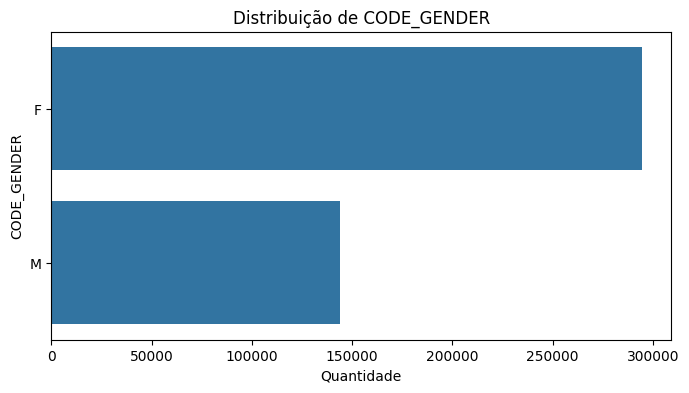

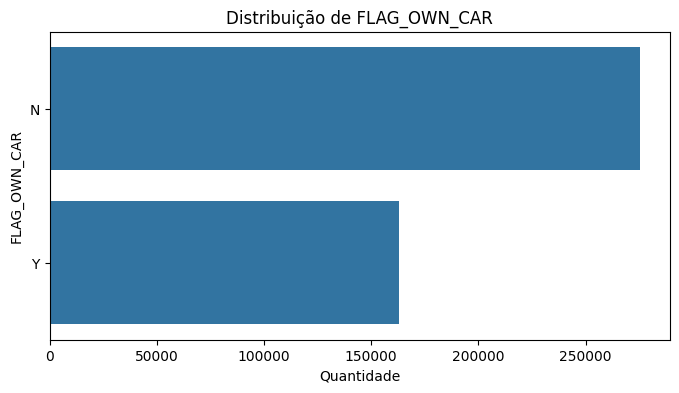

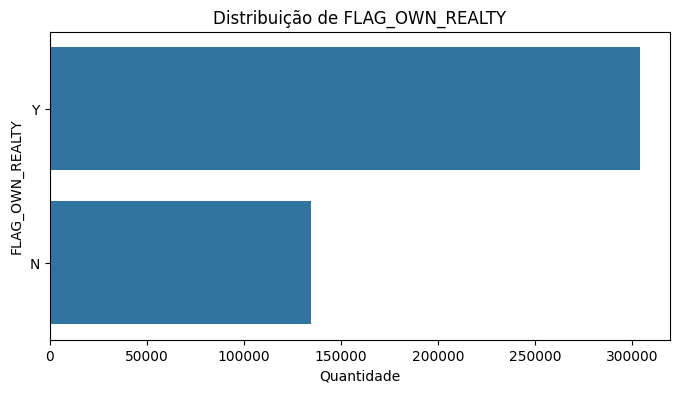

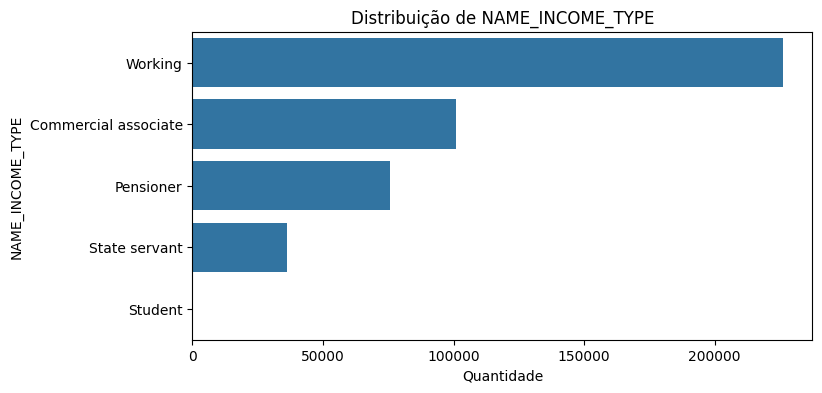

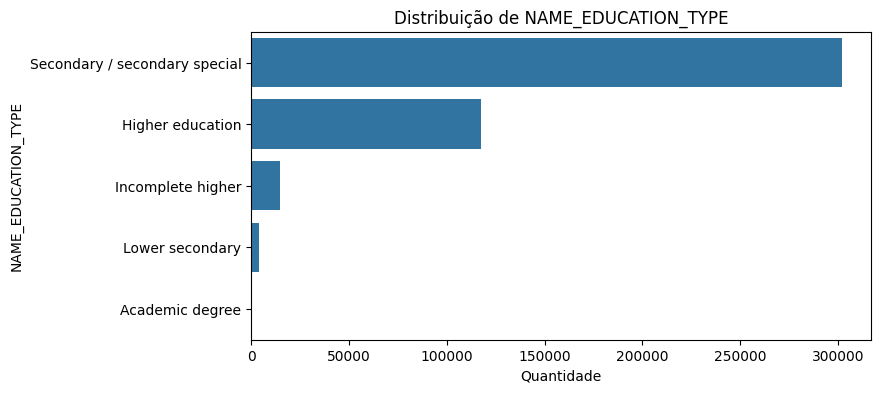

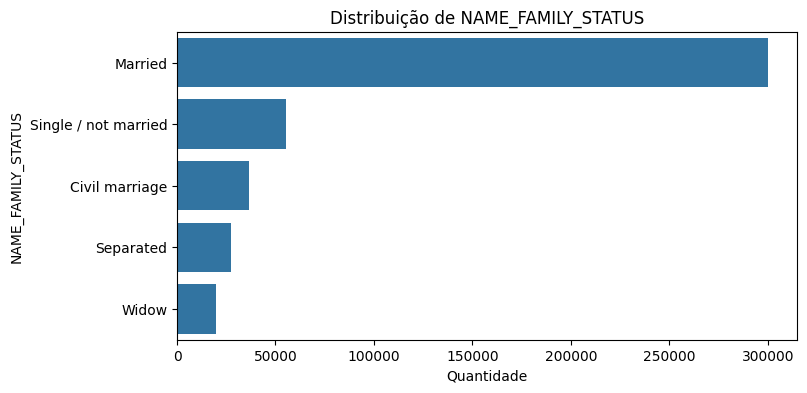

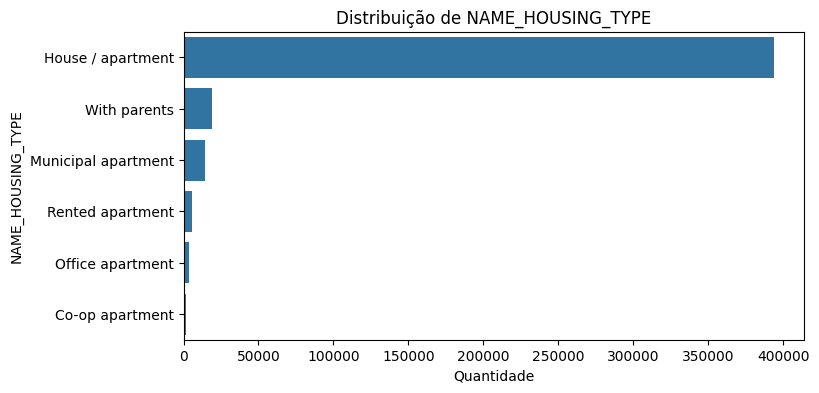

In [ ]:
# Gráficos de barras para variáveis categóricas.
# Esse tipo de gráfico é adequado para comparar a frequência de categorias.
# A orientação horizontal melhora a leitura dos rótulos.

cols_plot = [
    "CODE_GENDER",
    "FLAG_OWN_CAR",
    "FLAG_OWN_REALTY",
    "NAME_INCOME_TYPE",
    "NAME_EDUCATION_TYPE",
    "NAME_FAMILY_STATUS",
    "NAME_HOUSING_TYPE"
]

for col in cols_plot:
    plt.figure(figsize=(8, 4))
    sns.countplot(
        data=app_raw,
        y=col,
        order=app_raw[col].value_counts().index
    )
    plt.title(f"Distribuição de {col}")
    plt.xlabel("Quantidade")
    plt.ylabel(col)
    plt.show()

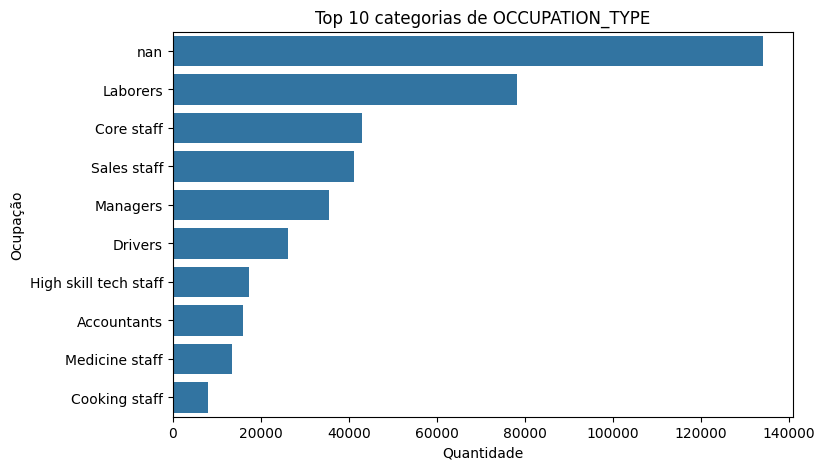

In [ ]:
# OCCUPATION_TYPE possui muitas categorias.
# Para manter a visualização legível, foram exibidas apenas as 10 categorias mais frequentes.

top_occupation = app_raw["OCCUPATION_TYPE"].value_counts(dropna=False).head(10)

plt.figure(figsize=(8, 5))
sns.barplot(
    x=top_occupation.values,
    y=top_occupation.index.astype(str)
)
plt.title("Top 10 categorias de OCCUPATION_TYPE")
plt.xlabel("Quantidade")
plt.ylabel("Ocupação")
plt.show()

## Investigação de possíveis valores extremos

Após a análise estatística inicial, foram investigados possíveis valores extremos nas variáveis `AMT_INCOME_TOTAL`, `CNT_CHILDREN` e `CNT_FAM_MEMBERS`.

A análise por percentis mostrou que a maior parte dos registros possui valores relativamente concentrados. No caso de `AMT_INCOME_TOTAL`, 99,9% dos registros possuem renda anual de até aproximadamente 990.000, enquanto o valor máximo observado é 6.750.000. Isso indica a presença de valores muito acima do padrão geral da base.

Para `CNT_CHILDREN`, observa-se que 99,9% dos registros possuem até 4 filhos, mas o valor máximo é 19. De forma semelhante, em `CNT_FAM_MEMBERS`, 99,9% dos registros possuem até 6 membros familiares, enquanto o valor máximo é 20.

Ao visualizar os maiores registros de `CNT_CHILDREN` e `CNT_FAM_MEMBERS`, percebe-se que os valores são coerentes entre si, pois os registros com maior quantidade de filhos também apresentam maior tamanho familiar. Ainda assim, esses valores são raros e devem ser avaliados com cautela.

Nesta etapa de análise exploratória, os valores extremos não serão removidos ou modificados. O objetivo da EDA é identificar padrões, levantar hipóteses e orientar decisões para o pré-processamento. A decisão sobre manter, transformar, agrupar ou limitar esses valores será registrada posteriormente no notebook `02_preprocessamento.ipynb`.

Para investigar os possíveis valores extremos, foram utilizados percentis e ordenações decrescentes das variáveis.

Os percentis ajudam a entender até que ponto os valores da base estão concentrados. Por exemplo, comparar o percentil 99,9% com o valor máximo permite identificar se o maior valor está muito distante do restante da distribuição.

Além disso, foram visualizados os maiores registros de renda, quantidade de filhos e tamanho da família. Essa análise permite verificar se os valores extremos aparecem isolados, se possuem coerência com outras variáveis e se podem representar possíveis erros ou apenas casos raros.


In [ ]:
numeric_cols = [
    "CNT_CHILDREN",
    "AMT_INCOME_TOTAL",
    "DAYS_BIRTH",
    "DAYS_EMPLOYED",
    "CNT_FAM_MEMBERS"
]

app_raw[numeric_cols].describe()

,CNT_CHILDREN,AMT_INCOME_TOTAL,DAYS_BIRTH,DAYS_EMPLOYED,CNT_FAM_MEMBERS
count,438557.000000,4.385570e+05,438557.000000,438557.000000,438557.000000
mean,0.427390,1.875243e+05,-15997.904649,60563.675328,2.194465
std,0.724882,1.100869e+05,4185.030007,138767.799647,0.897207
min,0.000000,2.610000e+04,-25201.000000,-17531.000000,1.000000
25%,0.000000,1.215000e+05,-19483.000000,-3103.000000,2.000000
50%,0.000000,1.607805e+05,-15630.000000,-1467.000000,2.000000
75%,1.000000,2.250000e+05,-12514.000000,-371.000000,3.000000
max,19.000000,6.750000e+06,-7489.000000,365243.000000,20.000000


In [ ]:
app_raw[["AMT_INCOME_TOTAL", "CNT_CHILDREN", "CNT_FAM_MEMBERS"]].quantile(
    [0.90, 0.95, 0.99, 0.995, 0.999]
)

,AMT_INCOME_TOTAL,CNT_CHILDREN,CNT_FAM_MEMBERS
0.900,315000.0,2.0,3.0
0.950,360000.0,2.0,4.0
0.990,540000.0,3.0,5.0
0.995,675000.0,3.0,5.0
0.999,990000.0,4.0,6.0


In [ ]:
app_raw.sort_values("AMT_INCOME_TOTAL", ascending=False)[
    ["ID", "AMT_INCOME_TOTAL", "NAME_INCOME_TYPE", "OCCUPATION_TYPE"]
].head(20)

,ID,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,OCCUPATION_TYPE
228161,5987966,6750000.0,Working,Laborers
228164,5987969,6750000.0,Working,Laborers
228163,5987968,6750000.0,Working,Laborers
228160,5987964,6750000.0,Working,Laborers
228159,5987963,6750000.0,Working,Laborers
421262,7987964,6750000.0,Working,Laborers
228162,5987967,6750000.0,Working,Laborers
282693,6123715,4500000.0,Working,Managers
282694,6272042,4500000.0,Working,Managers
282687,6123707,4500000.0,Working,Managers


In [ ]:
app_raw.sort_values("CNT_FAM_MEMBERS", ascending=False)[
    ["ID", "CNT_CHILDREN", "CNT_FAM_MEMBERS", "NAME_FAMILY_STATUS"]
].head(20)

,ID,CNT_CHILDREN,CNT_FAM_MEMBERS,NAME_FAMILY_STATUS
36388,5105054,19,20.0,Single / not married
20442,5061210,14,15.0,Separated
20443,5061211,14,15.0,Separated
20441,5061207,14,15.0,Separated
208911,5931570,12,14.0,Married
208912,5931571,12,14.0,Married
208910,5931569,12,14.0,Married
208909,5931568,12,14.0,Married
79647,5372460,9,11.0,Civil marriage
79646,5307274,9,11.0,Civil marriage


In [ ]:
app_raw.sort_values("CNT_CHILDREN", ascending=False)[
    ["ID", "CNT_CHILDREN", "CNT_FAM_MEMBERS", "NAME_FAMILY_STATUS"]
].head(20)

,ID,CNT_CHILDREN,CNT_FAM_MEMBERS,NAME_FAMILY_STATUS
36388,5105054,19,20.0,Single / not married
20443,5061211,14,15.0,Separated
20442,5061210,14,15.0,Separated
20441,5061207,14,15.0,Separated
208912,5931571,12,14.0,Married
208909,5931568,12,14.0,Married
208911,5931570,12,14.0,Married
208910,5931569,12,14.0,Married
79646,5307274,9,11.0,Civil marriage
79645,5307273,9,11.0,Civil marriage


## Visualização das variáveis temporais

Para analisar as variáveis `AGE_YEARS` e `EMPLOYED_YEARS`, foram utilizados histogramas e boxplots.

O histograma foi escolhido porque é uma das formas mais adequadas de visualizar variáveis numéricas contínuas. Esse tipo de gráfico permite observar como os valores estão distribuídos ao longo da população, identificando regiões de maior concentração, dispersão, assimetrias e possíveis padrões na distribuição dos dados.

Além das barras do histograma, foi incluída uma curva de densidade (`Kernel Density Estimation - KDE`). Essa linha suavizada representa uma estimativa da distribuição dos dados e auxilia na identificação do formato geral da distribuição, tornando mais fácil visualizar tendências que podem não ser percebidas apenas pelas barras de frequência.

Também foram utilizados boxplots para complementar a análise. O boxplot resume a distribuição por meio da mediana, quartis e amplitude dos dados, além de destacar possíveis valores extremos. Esse tipo de gráfico é útil para identificar observações que se afastam significativamente do comportamento predominante da base.

A utilização conjunta de histogramas e boxplots permite compreender tanto a forma geral da distribuição quanto a presença de possíveis valores extremos, fornecendo uma visão mais completa das variáveis analisadas.

## Interpretação dos resultados

A distribuição da idade mostra que a maior parte dos clientes está concentrada entre aproximadamente 30 e 55 anos, com média de 43,8 anos e mediana de 42,8 anos. Os valores observados são compatíveis com o perfil esperado de solicitantes de crédito e não foram identificadas idades fora de uma faixa plausível.

Em relação ao tempo de emprego, observa-se uma concentração de clientes com poucos anos de vínculo empregatício, acompanhada por uma cauda à direita formada por indivíduos com carreiras mais longas. A média de aproximadamente 7,2 anos é superior à mediana de 5,3 anos, indicando a presença dessa assimetria.

Os boxplots não indicam valores impossíveis após a remoção do valor especial identificado em `DAYS_EMPLOYED`, embora existam registros com longos períodos de emprego, o que é esperado em uma população com ampla faixa etária.

In [ ]:
import numpy as np

app_eda = app_raw.copy()

app_eda["AGE_YEARS"] = (
    -app_eda["DAYS_BIRTH"] / 365
).round(1)

app_eda["EMPLOYED_YEARS"] = np.where(
    app_eda["DAYS_EMPLOYED"] == 365243,
    np.nan,
    -app_eda["DAYS_EMPLOYED"] / 365
)

app_eda["EMPLOYED_YEARS"] = (
    app_eda["EMPLOYED_YEARS"]
    .round(1)
)

In [ ]:
app_eda[[
    "AGE_YEARS",
    "EMPLOYED_YEARS"
]].describe()

,AGE_YEARS,EMPLOYED_YEARS
count,438557.000000,363228.000000
mean,43.830089,7.186540
std,11.465683,6.574301
min,20.500000,0.000000
25%,34.300000,2.500000
50%,42.800000,5.300000
75%,53.400000,9.600000
max,69.000000,48.000000


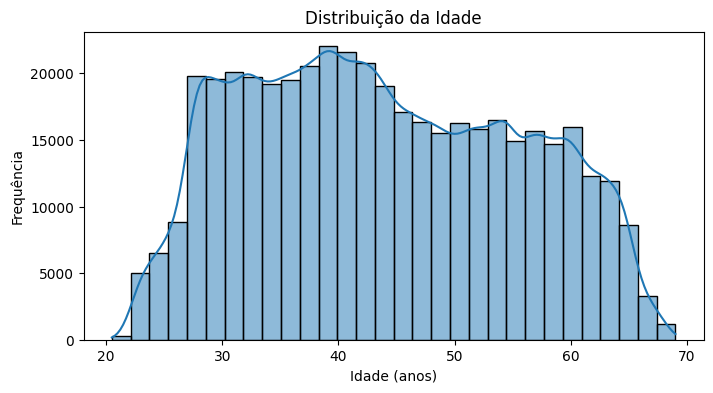

In [ ]:
plt.figure(figsize=(8,4))

sns.histplot(
    app_eda["AGE_YEARS"],
    bins=30,
    kde=True
)

plt.title("Distribuição da Idade")
plt.xlabel("Idade (anos)")
plt.ylabel("Frequência")

plt.show()

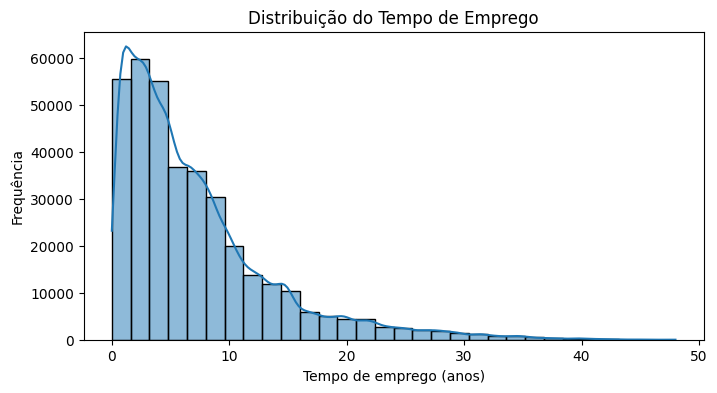

In [ ]:
plt.figure(figsize=(8,4))

sns.histplot(
    app_eda["EMPLOYED_YEARS"].dropna(),
    bins=30,
    kde=True
)

plt.title("Distribuição do Tempo de Emprego")
plt.xlabel("Tempo de emprego (anos)")
plt.ylabel("Frequência")

plt.show()

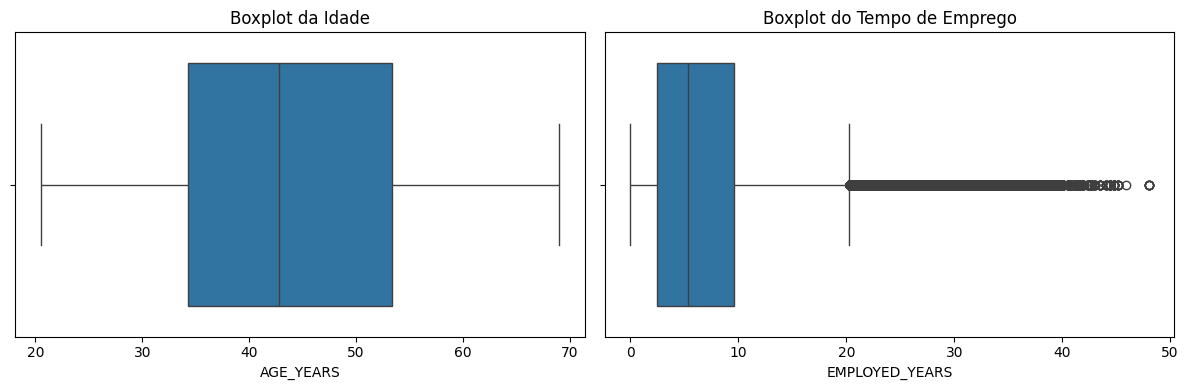

In [ ]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(12,4)
)

sns.boxplot(
    x=app_eda["AGE_YEARS"],
    ax=axes[0]
)

axes[0].set_title("Boxplot da Idade")

sns.boxplot(
    x=app_eda["EMPLOYED_YEARS"],
    ax=axes[1]
)

axes[1].set_title("Boxplot do Tempo de Emprego")

plt.tight_layout()
plt.show()

## Análise da variável STATUS

A coluna `STATUS` representa a situação mensal de pagamento de cada cliente na base `credit_record`.

Foram analisadas as distribuições absoluta e percentual dos diferentes status para compreender o comportamento geral do histórico de crédito disponível.

Para essa análise foi utilizado um gráfico de barras, pois a variável é categórica. Esse tipo de visualização facilita a comparação entre categorias e permite identificar rapidamente quais situações de pagamento são mais frequentes.

Observa-se que a maior parte dos registros está concentrada nos status `C`, `0` e `X`.

- `C` representa pagamentos quitados no mês;
- `0` representa atraso entre 1 e 29 dias;
- `X` indica ausência de empréstimo naquele mês.

Os demais status representam atrasos mais severos e aparecem com frequência muito reduzida. Em especial, os status `2`, `3`, `4` e `5`, associados a atrasos iguais ou superiores a 60 dias, representam uma parcela pequena da base.

Esse resultado sugere que eventos de inadimplência grave são relativamente raros no nível mensal, antecipando o desbalanceamento observado posteriormente na construção da variável alvo.

In [ ]:
credit_raw["STATUS"].value_counts().sort_index()

,count
STATUS,
0,383120
1,11090
2,868
3,320
4,223
5,1693
C,442031
X,209230


In [ ]:
(
    credit_raw["STATUS"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
).round(2)

,proportion
STATUS,
0,36.54
1,1.06
2,0.08
3,0.03
4,0.02
5,0.16
C,42.16
X,19.95


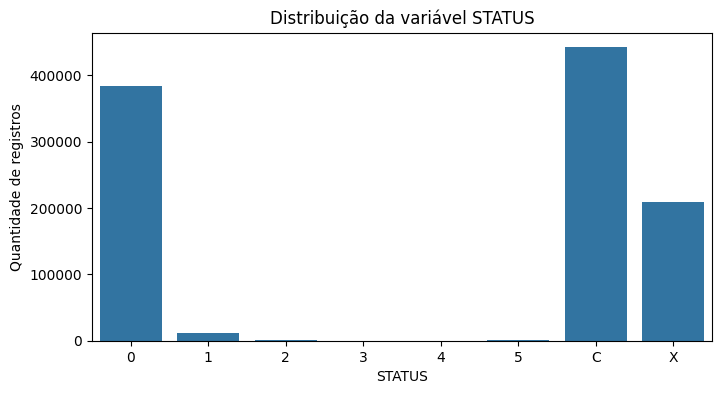

In [ ]:
plt.figure(figsize=(8,4))

sns.countplot(
    data=credit_raw,
    x="STATUS",
    order=sorted(credit_raw["STATUS"].unique())
)

plt.title("Distribuição da variável STATUS")
plt.xlabel("STATUS")
plt.ylabel("Quantidade de registros")

plt.show()

## Análise da variável MONTHS_BALANCE

A coluna `MONTHS_BALANCE` representa o mês de referência de cada registro em relação ao momento atual.

De acordo com a documentação da base, o valor `0` representa o mês mais recente disponível, enquanto os valores negativos representam meses anteriores. Por exemplo, `-1` corresponde ao mês anterior, `-2` a dois meses antes e assim sucessivamente.

Foi utilizado um histograma para visualizar a distribuição temporal dos registros. Esse tipo de gráfico é adequado para variáveis numéricas contínuas, pois permite observar a concentração das observações ao longo do período analisado e identificar possíveis padrões de distribuição.

O histograma mostra um crescimento gradual da quantidade de registros à medida que os meses se aproximam do período mais recente. Esse comportamento sugere que parte dos clientes possui histórico mais curto, enquanto outros apresentam períodos de observação mais longos.

A análise estatística indica que a base contém registros entre os meses `-60` e `0`, correspondendo a aproximadamente cinco anos de histórico de crédito. A mediana igual a `-17` indica que metade dos registros está concentrada nos 17 meses mais recentes da base.

In [ ]:
credit_raw["MONTHS_BALANCE"].describe()

,MONTHS_BALANCE
count,1.048575e+06
mean,-1.913700e+01
std,1.402350e+01
min,-6.000000e+01
25%,-2.900000e+01
50%,-1.700000e+01
75%,-7.000000e+00
max,0.000000e+00


In [ ]:
print("Mês mais antigo:", credit_raw["MONTHS_BALANCE"].min())
print("Mês mais recente:", credit_raw["MONTHS_BALANCE"].max())

Mês mais antigo: -60
Mês mais recente: 0


<Axes: xlabel='MONTHS_BALANCE', ylabel='Count'>

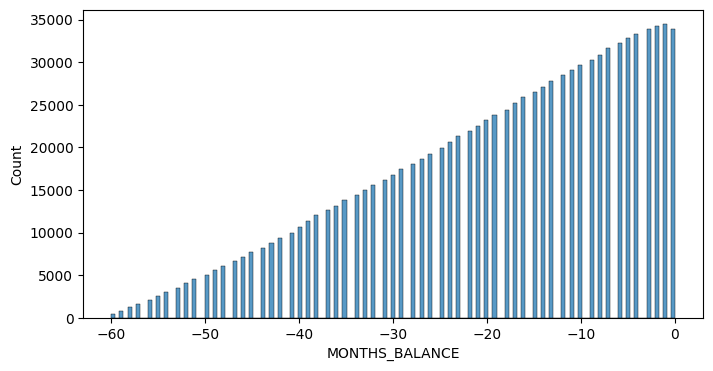

In [ ]:
plt.figure(figsize=(8,4))

sns.histplot(
    credit_raw["MONTHS_BALANCE"])

## Quantidade de meses por cliente

Como a base `credit_record` está estruturada no nível cliente-mês, cada cliente pode possuir diferentes quantidades de registros ao longo do tempo.

Para investigar essa característica foi calculada a quantidade de meses observados para cada cliente.

Foi utilizado um histograma para visualizar a distribuição da quantidade de registros por cliente. Esse tipo de gráfico é adequado para variáveis numéricas porque permite identificar regiões de maior concentração, dispersão e assimetrias na distribuição.

Observa-se que os clientes possuem diferentes quantidades de histórico disponível. A média é de aproximadamente 22,8 meses por cliente, enquanto a mediana é de 19 meses. O menor histórico observado possui apenas 1 mês, enquanto o maior possui 61 meses.

A distribuição apresenta assimetria à direita, indicando que clientes com períodos muito longos de observação são menos frequentes que clientes com histórico mais curto.

Esse resultado é relevante para o problema de crédito, pois clientes com maior quantidade de meses observados possuem mais oportunidades de apresentar eventos de atraso. Portanto, o tamanho do histórico disponível deve ser considerado na interpretação da variável alvo construída posteriormente.

In [ ]:
meses_por_cliente = (
    credit_raw
    .groupby("ID")["MONTHS_BALANCE"]
    .count()
)

meses_por_cliente.describe()

,MONTHS_BALANCE
count,45985.000000
mean,22.802544
std,15.492771
min,1.000000
25%,10.000000
50%,19.000000
75%,34.000000
max,61.000000


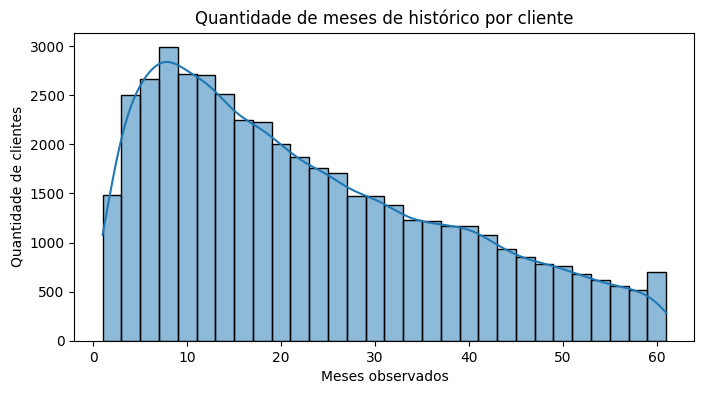

In [ ]:
plt.figure(figsize=(8,4))

sns.histplot(
    meses_por_cliente,
    bins=30,
    kde=True
)

plt.title("Quantidade de meses de histórico por cliente")
plt.xlabel("Meses observados")
plt.ylabel("Quantidade de clientes")

plt.show()

## Principais insights da análise exploratória

A análise exploratória permitiu compreender a estrutura e as principais características das bases `application_record` e `credit_record`.

Os principais achados foram:

- A base cadastral apresenta poucos problemas de qualidade de dados, sendo que a principal variável com valores ausentes é `OCCUPATION_TYPE`.
- Foram identificados IDs duplicados em `application_record`, indicando a necessidade de tratamento antes da integração com outras bases.
- As variáveis categóricas mostram predominância de clientes com renda do tipo `Working`, escolaridade `Secondary / secondary special`, estado civil `Married` e moradia do tipo `House / apartment`.
- Foram identificados valores extremos em variáveis como renda anual, quantidade de filhos e tamanho da família. Esses registros não foram removidos nesta etapa, sendo reservada para o pré-processamento a decisão sobre eventuais transformações.
- A população analisada é composta predominantemente por adultos em idade economicamente ativa, com média aproximada de 44 anos.
- O tempo de emprego apresenta distribuição assimétrica, com concentração em períodos mais curtos e alguns clientes com longos históricos profissionais.
- Na base `credit_record`, a maior parte dos registros está concentrada nos status `C`, `0` e `X`, enquanto eventos de inadimplência grave são relativamente raros.
- O histórico de crédito disponível cobre até 60 meses de observação, porém os clientes possuem diferentes quantidades de meses registrados.
- A quantidade de histórico varia consideravelmente entre os clientes, fator que deve ser considerado na construção e interpretação da variável alvo.

Esses resultados forneceram subsídios para as decisões adotadas posteriormente no notebook de pré-processamento e para o desenvolvimento dos modelos de classificação de risco de crédito.